# 🌍 Customer Intelligence System — Country Socio-Economic Analysis
**Dataset:** Unsupervised Learning on Country Data (Kaggle — rohan0301) | 167 countries × 9 features  
**Pipeline:** EDA → Preprocessing → PCA → K-Means Clustering → DBSCAN → Classification → Ensemble Learning (RF + XGBoost)


## 0. Setup & Imports

In [1]:
!pip install xgboost scikit-learn imbalanced-learn -q

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA


from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score, roc_curve)
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')
print("✅ All imports successful")


✅ All imports successful


## 1. Data Loading
Download `Country-data.csv` from [Kaggle](https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data), upload it here, then run the cell below.  
The fallback synthetic block runs automatically if no file is uploaded.


In [2]:
import os

if os.path.exists('Country-data.csv'):
    df = pd.read_csv('Country-data.csv')
    print("✅ Loaded real dataset from Kaggle")
else:
    np.random.seed(42)
    n = 167
    gdpp    = np.random.exponential(scale=12000, size=n).clip(200, 105000).astype(int)
    income  = (gdpp * np.random.uniform(0.6, 1.5, n)).clip(500, 120000).astype(int)

    df = pd.DataFrame({
        'country':    [f'Country_{i:03d}' for i in range(n)],
        'child_mort': np.clip(120 - gdpp/1200 + np.random.normal(0, 15, n), 1, 170).round(1),
        'exports':    np.random.uniform(5, 80, n).round(1),
        'health':     np.clip(3 + gdpp/25000 + np.random.normal(0, 1.5, n), 1.5, 17).round(2),
        'imports':    np.random.uniform(10, 90, n).round(1),
        'income':     income,
        'inflation':  np.clip(np.random.exponential(6, n), 0.2, 50).round(2),
        'life_expec': np.clip(45 + gdpp/2500 + np.random.normal(0, 5, n), 45, 85).round(1),
        'total_fer':  np.clip(7 - gdpp/30000 + np.random.normal(0, 0.8, n), 1.1, 7.5).round(2),
        'gdpp':       gdpp,
    })
    print("⚠️  Using synthetic dataset — upload Country-data.csv from Kaggle for real results")

print(f"Shape: {df.shape}")
df.head(10)


⚠️  Using synthetic dataset — upload Country-data.csv from Kaggle for real results
Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Country_000,122.0,57.8,5.28,54.3,4323,7.14,45.9,7.50,5631
1,Country_001,101.5,21.0,3.55,62.1,22998,1.00,57.4,4.00,36121
2,Country_002,92.9,15.2,4.51,76.4,17882,10.15,63.3,5.93,15800
3,Country_003,110.0,6.1,2.96,26.5,13253,1.53,49.3,6.68,10955
4,Country_004,69.7,31.3,2.60,10.9,1251,1.52,48.4,7.50,2035
5,Country_005,102.9,49.2,3.90,21.0,2158,4.62,54.7,6.57,2035
6,Country_006,115.6,34.4,4.58,82.0,577,5.39,45.0,6.96,718
7,Country_007,81.2,37.8,1.50,79.9,28493,5.21,54.8,5.27,24134
8,Country_008,135.3,72.8,3.98,57.8,8347,0.58,48.1,5.41,11028
9,Country_009,86.2,31.1,3.19,58.0,18052,12.60,50.5,7.50,14775


## 2. Exploratory Data Analysis (EDA)

In [3]:
print("=== DATA INFO ==="); df.info()
print("\n=== MISSING VALUES ==="); print(df.isnull().sum())
print("\n=== DESCRIPTIVE STATS ===")
display(df.describe().T.round(2))


=== DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB

=== MISSING VALUES ===
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

=== DESCRIPTIVE STATS ===


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,111.80,16.61,54.5,102.70,113.30,122.80,149.80
exports,167.0,38.41,20.98,6.1,19.00,35.80,54.25,79.20
health,167.0,3.46,1.39,1.5,2.20,3.45,4.41,7.62
imports,167.0,51.41,24.12,10.9,29.35,52.30,72.65,89.80
income,167.0,11834.99,12329.62,500.0,3166.50,8016.00,16615.50,63310.00
inflation,167.0,6.22,5.75,0.2,1.86,5.00,8.91,35.11
life_expec,167.0,50.61,5.73,45.0,45.20,49.30,53.45,69.50
total_fer,167.0,6.57,0.77,4.0,6.06,6.71,7.22,7.50
gdpp,167.0,11218.05,11131.62,200.0,3110.50,7668.00,16352.00,52009.00


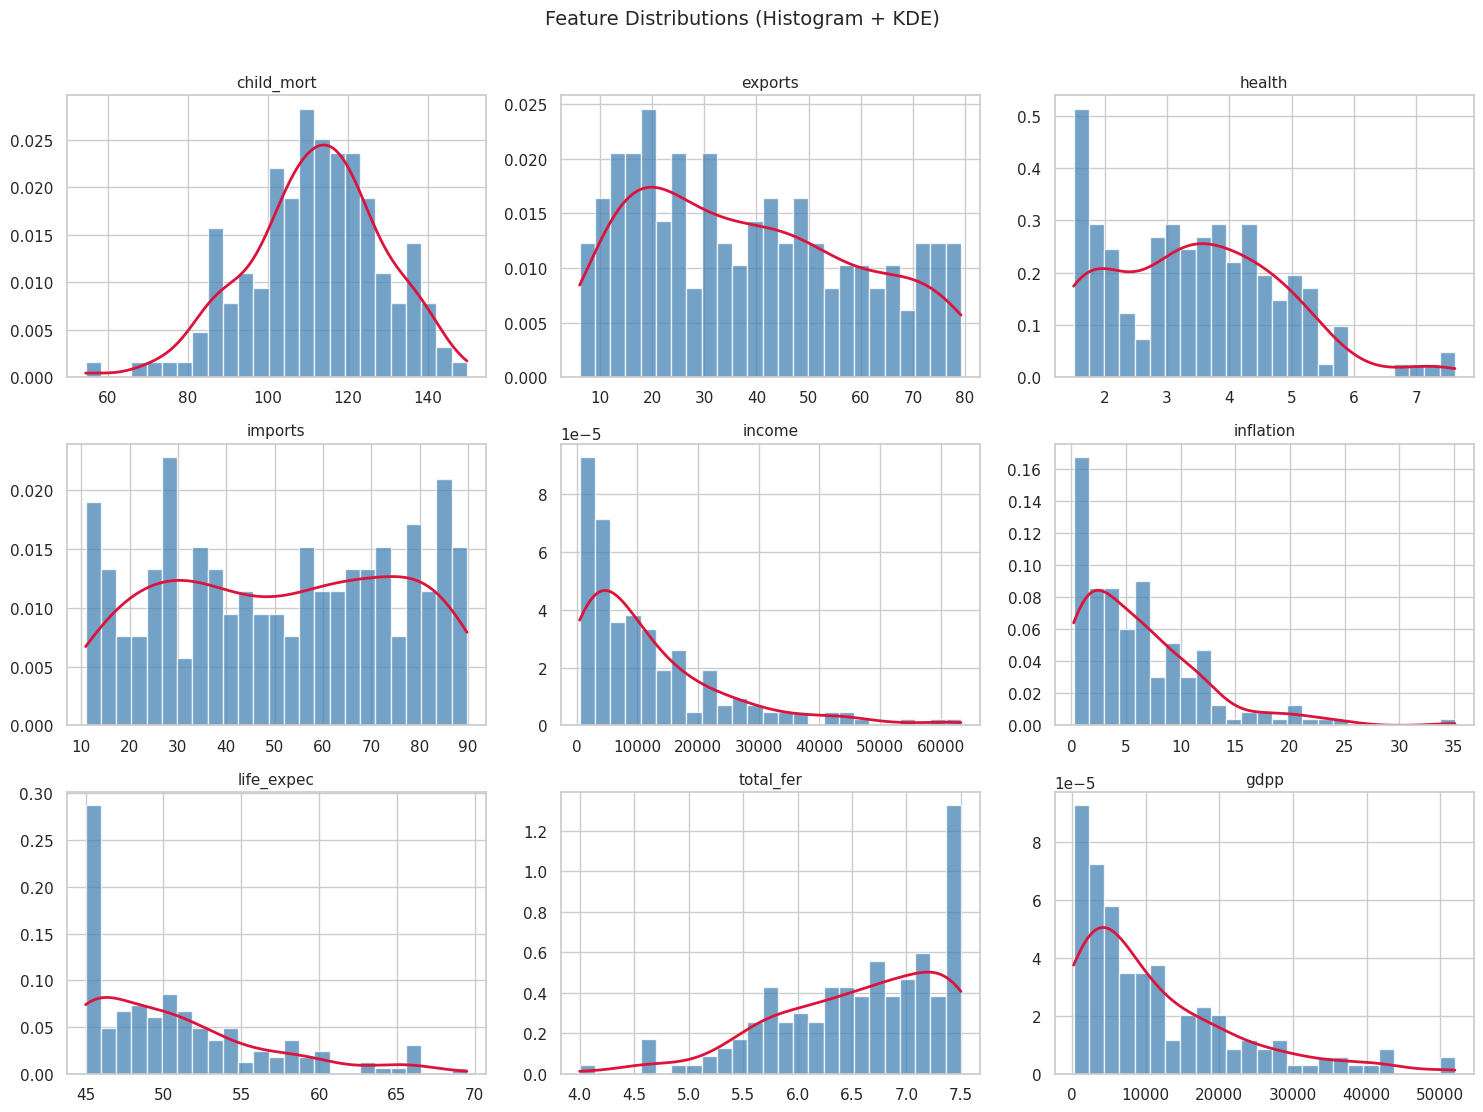

In [4]:
features = ['child_mort','exports','health','imports','income','inflation','life_expec','total_fer','gdpp']

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()
for i, feat in enumerate(features):
    axes[i].hist(df[feat], bins=25, color='steelblue', edgecolor='white', density=True, alpha=0.75)
    kde = stats.gaussian_kde(df[feat].dropna())
    xs = np.linspace(df[feat].min(), df[feat].max(), 200)
    axes[i].plot(xs, kde(xs), color='crimson', lw=2)
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('')
plt.suptitle('Feature Distributions (Histogram + KDE)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


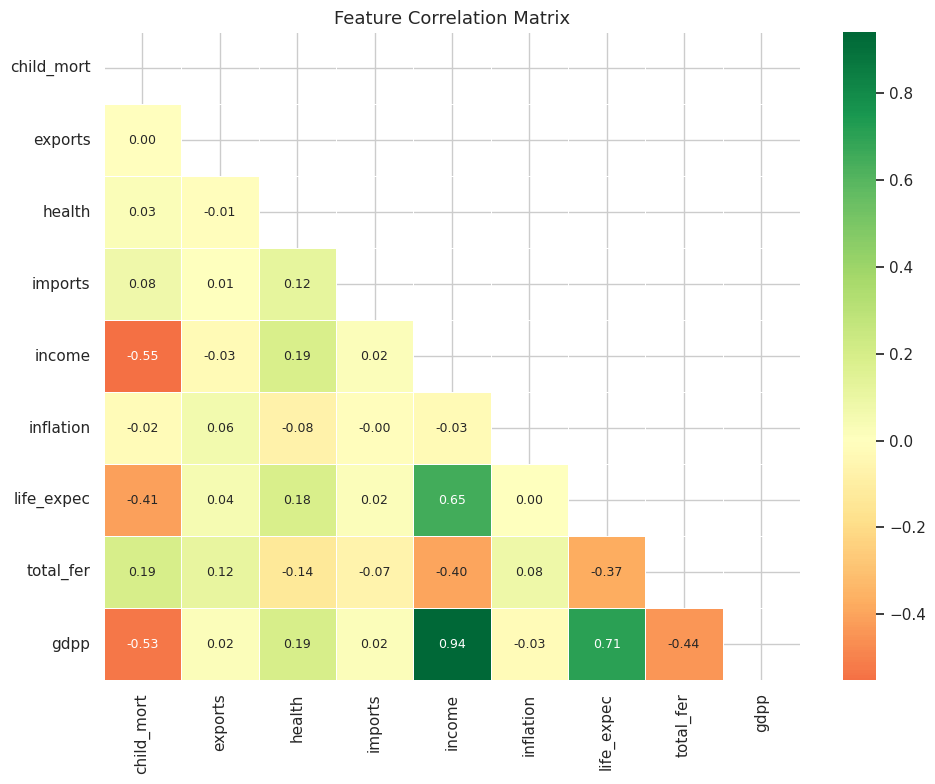

Top 5 positive correlations:
income      gdpp          0.940460
life_expec  gdpp          0.707844
income      life_expec    0.645573
child_mort  total_fer     0.194716
health      gdpp          0.188520

Top 5 negative correlations:
income      total_fer    -0.399391
child_mort  life_expec   -0.412747
total_fer   gdpp         -0.437085
child_mort  gdpp         -0.531350
            income       -0.552134


In [5]:
# Correlation Heatmap
corr = df[features].corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', mask=mask,
            ax=ax, center=0, linewidths=0.5, annot_kws={'size':9})
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout(); plt.show()

top = corr.unstack().drop_duplicates().sort_values(ascending=False)
print("Top 5 positive correlations:")
print(top[top < 1].head(5).to_string())
print("\nTop 5 negative correlations:")
print(top.tail(5).to_string())


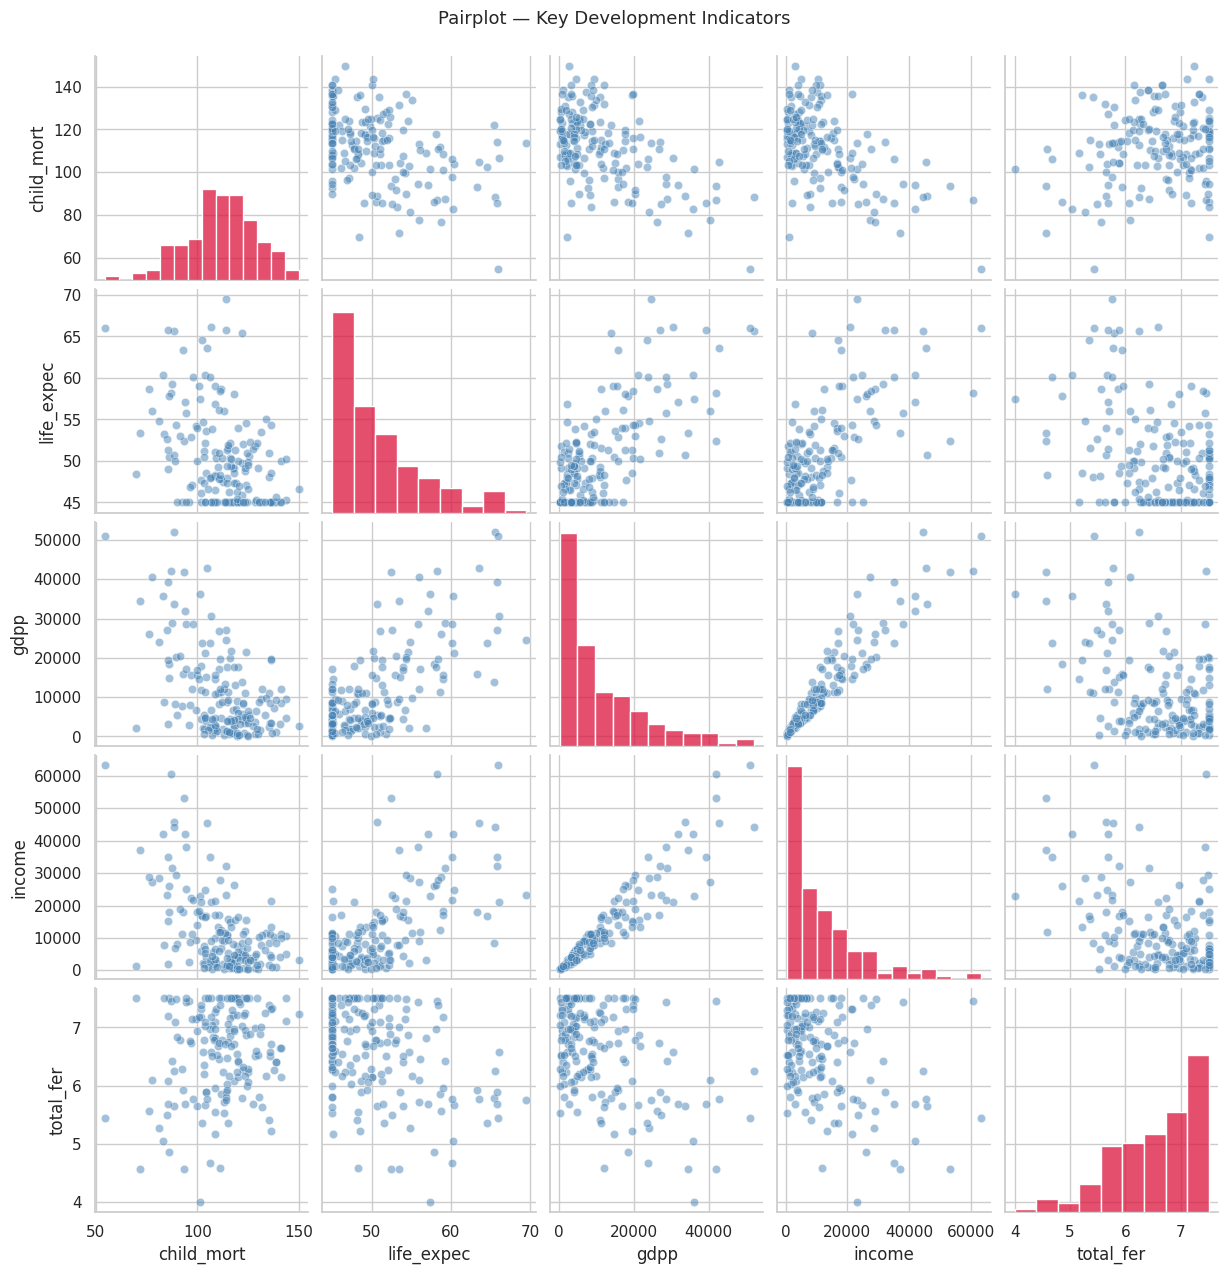

In [6]:
pair_cols = ['child_mort', 'life_expec', 'gdpp', 'income', 'total_fer']
g = sns.pairplot(df[pair_cols], plot_kws={'alpha':0.5, 'color':'steelblue'},
                 diag_kws={'color':'crimson'})
g.fig.suptitle('Pairplot — Key Development Indicators', y=1.02, fontsize=13)
plt.show()


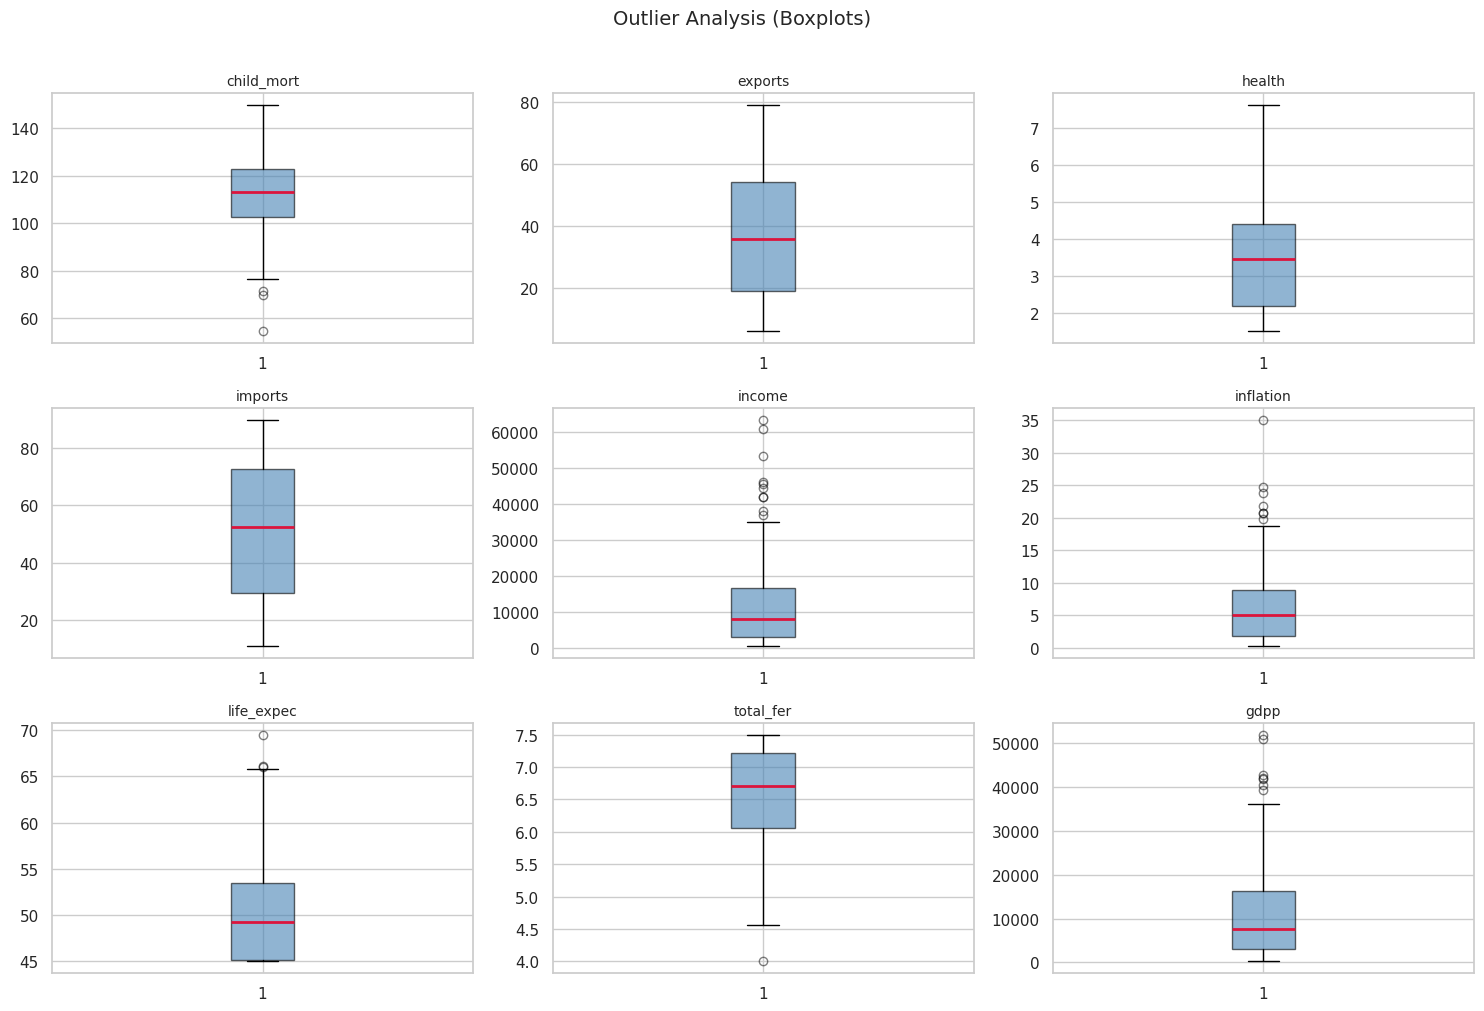

Outlier counts (IQR method):
  child_mort     : 3
  exports        : 0
  health         : 0
  imports        : 0
  income         : 10
  inflation      : 7
  life_expec     : 3
  total_fer      : 1
  gdpp           : 7


In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, feat in enumerate(features):
    axes[i].boxplot(df[feat].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='crimson', lw=2),
                    flierprops=dict(marker='o', color='gray', alpha=0.5))
    axes[i].set_title(feat, fontsize=10)
plt.suptitle('Outlier Analysis (Boxplots)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

print("Outlier counts (IQR method):")
for feat in features:
    Q1, Q3 = df[feat].quantile(0.25), df[feat].quantile(0.75)
    IQR = Q3 - Q1
    out = ((df[feat] < Q1 - 1.5*IQR) | (df[feat] > Q3 + 1.5*IQR)).sum()
    print(f"  {feat:15s}: {out}")


## 3. Preprocessing & Feature Engineering

In [8]:
X_raw = df[features].copy()
country_names = df['country'].values

skewed_feats = ['child_mort', 'income', 'gdpp', 'inflation']
for feat in skewed_feats:
    X_raw[feat + '_log'] = np.log1p(X_raw[feat])
    print(f"Skewness of {feat}: {X_raw[feat].skew():.2f} → log: {X_raw[feat+'_log'].skew():.2f}")

model_feats = [f for f in features if f not in skewed_feats] + [f+'_log' for f in skewed_feats]
X = X_raw[model_feats].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=model_feats)

print(f"\nFinal feature matrix: {X_scaled.shape}")
print("Features used:", model_feats)


Skewness of child_mort: -0.38 → log: -0.96
Skewness of income: 1.79 → log: -0.44
Skewness of gdpp: 1.48 → log: -0.63
Skewness of inflation: 1.67 → log: -0.15

Final feature matrix: (167, 9)
Features used: ['exports', 'health', 'imports', 'life_expec', 'total_fer', 'child_mort_log', 'income_log', 'gdpp_log', 'inflation_log']


## 4. Dimensionality Reduction — PCA

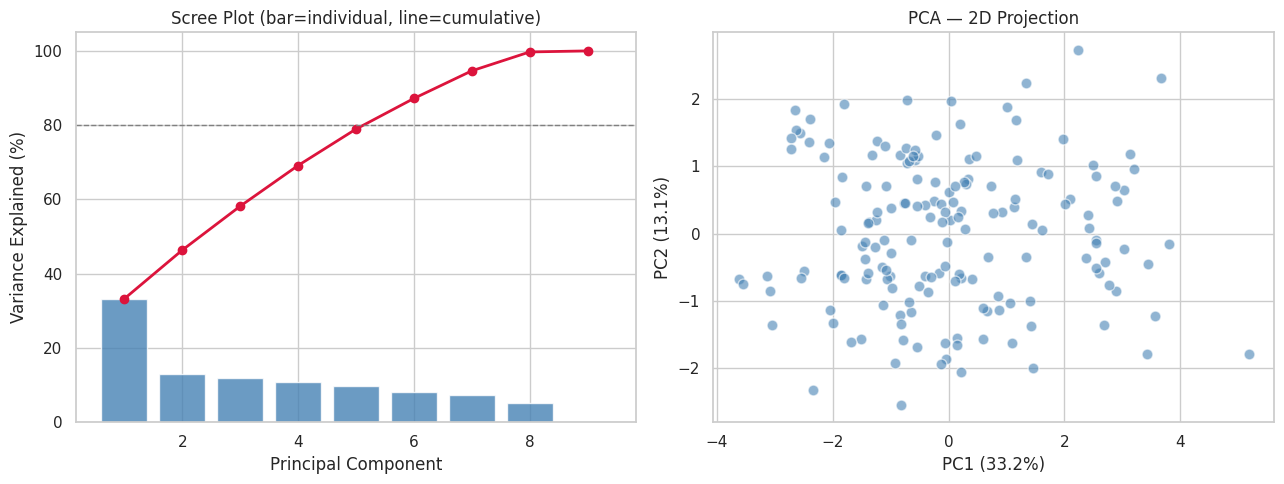

Components needed for 80% variance: 6
PC1+PC2 together explain: 46.3% of variance


In [9]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(range(1, len(explained_var)+1), explained_var*100, color='steelblue', alpha=0.8)
axes[0].plot(range(1, len(explained_var)+1), cumulative_var*100, 'o-', color='crimson', lw=2)
axes[0].axhline(80, color='gray', ls='--', lw=1)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot (bar=individual, line=cumulative)')

pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)
axes[1].scatter(X_pca2[:,0], X_pca2[:,1], alpha=0.6, color='steelblue', edgecolors='white', s=60)
axes[1].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('PCA — 2D Projection')

plt.tight_layout(); plt.show()

n_pc_80 = np.argmax(cumulative_var >= 0.80) + 1
print(f"Components needed for 80% variance: {n_pc_80}")
print(f"PC1+PC2 together explain: {cumulative_var[1]*100:.1f}% of variance")


PCA Loadings (top absolute values = most influential features):


,PC1,PC2,PC3
income_log,0.528,-0.047,0.071
gdpp_log,0.527,-0.043,0.092
life_expec,0.452,-0.010,0.007
child_mort_log,-0.344,0.366,0.092
total_fer,-0.311,-0.214,0.330
health,0.125,0.614,0.073
inflation_log,-0.085,-0.104,-0.431
imports,0.039,0.641,0.098
exports,-0.006,-0.133,0.818


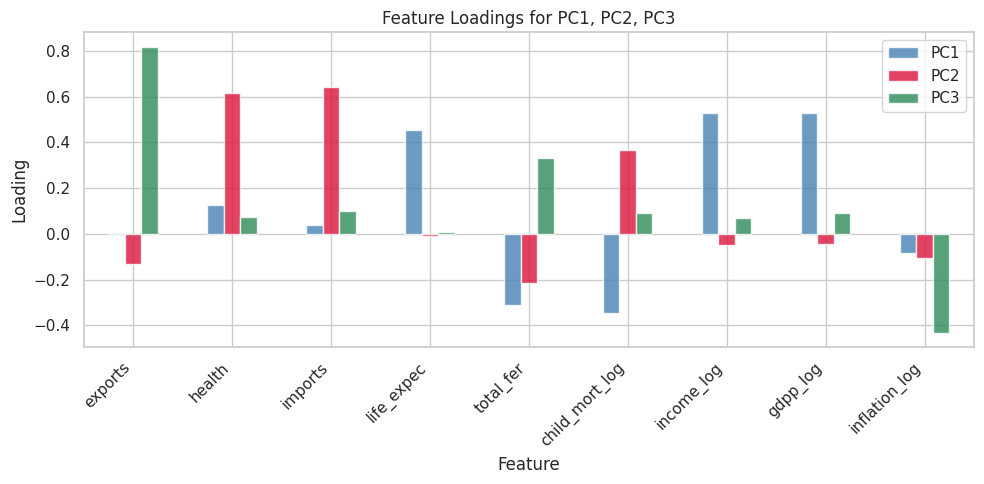

In [10]:
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

loadings = pd.DataFrame(pca3.components_.T, index=model_feats,
                         columns=['PC1', 'PC2', 'PC3']).round(3)
print("PCA Loadings (top absolute values = most influential features):")
display(loadings.sort_values('PC1', key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
loadings[['PC1','PC2','PC3']].plot(kind='bar', ax=ax,
                                    color=['steelblue','crimson','seagreen'], alpha=0.8)
ax.set_title('Feature Loadings for PC1, PC2, PC3')
ax.set_xlabel('Feature'); ax.set_ylabel('Loading')
ax.legend(); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


## 5. K-Means Clustering

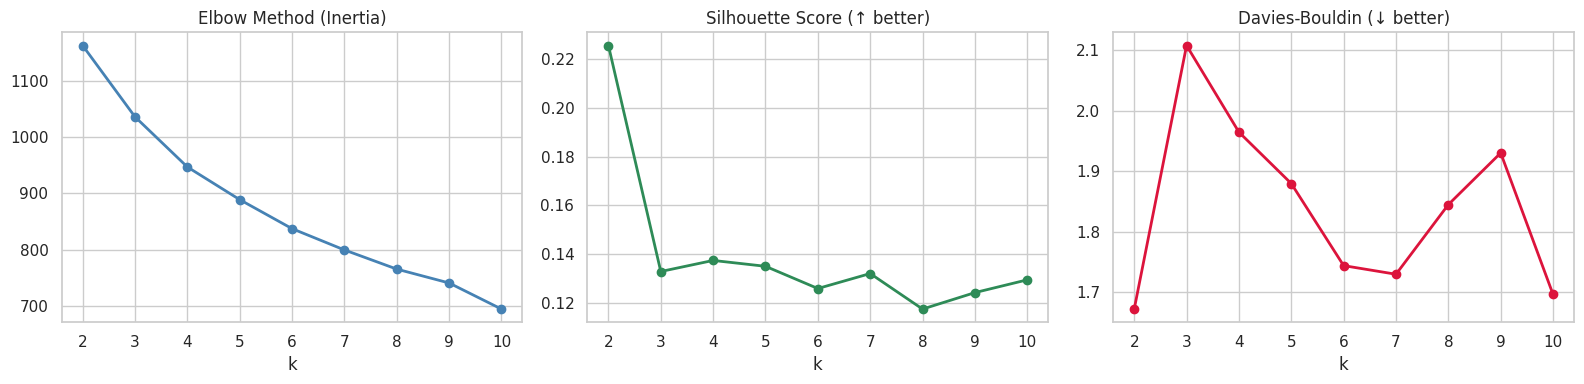

Best k by Silhouette: 2  (score=0.2257)


In [11]:
inertias, silhouettes, db_scores = [], [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(K_range, inertias, 'o-', color='steelblue', lw=2); axes[0].set_title('Elbow Method (Inertia)'); axes[0].set_xlabel('k')
axes[1].plot(K_range, silhouettes, 'o-', color='seagreen', lw=2); axes[1].set_title('Silhouette Score (↑ better)'); axes[1].set_xlabel('k')
axes[2].plot(K_range, db_scores, 'o-', color='crimson', lw=2); axes[2].set_title('Davies-Bouldin (↓ better)'); axes[2].set_xlabel('k')
plt.tight_layout(); plt.show()

best_k = K_range[np.argmax(silhouettes)]
print(f"Best k by Silhouette: {best_k}  (score={max(silhouettes):.4f})")


Cluster sizes:
0     50
1    117


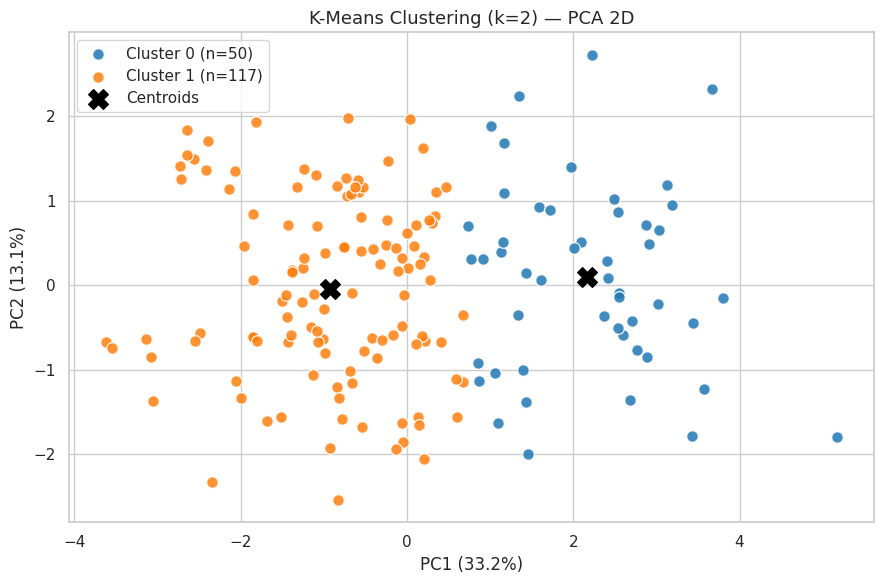

In [12]:
OPTIMAL_K = best_k
km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=20)
km_labels = km_final.fit_predict(X_scaled)

df['KMeans_Cluster'] = km_labels

print("Cluster sizes:")
print(pd.Series(km_labels).value_counts().sort_index().to_string())

colors_palette = plt.cm.tab10.colors
fig, ax = plt.subplots(figsize=(9, 6))
for cl in range(OPTIMAL_K):
    mask = km_labels == cl
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               label=f'Cluster {cl} (n={mask.sum()})',
               color=colors_palette[cl], edgecolors='white', s=70, alpha=0.85)

centers_pca = pca2.transform(km_final.cluster_centers_)
ax.scatter(centers_pca[:,0], centers_pca[:,1], marker='X', s=200, c='black', zorder=5, label='Centroids')
ax.set_title(f'K-Means Clustering (k={OPTIMAL_K}) — PCA 2D', fontsize=13)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)'); ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(); plt.tight_layout(); plt.show()


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,99.75,37.23,3.97,53.34,25890.34,5.83,57.07,5.95,24472.92
1,116.94,38.92,3.24,50.59,5828.44,6.39,47.84,6.83,5553.57


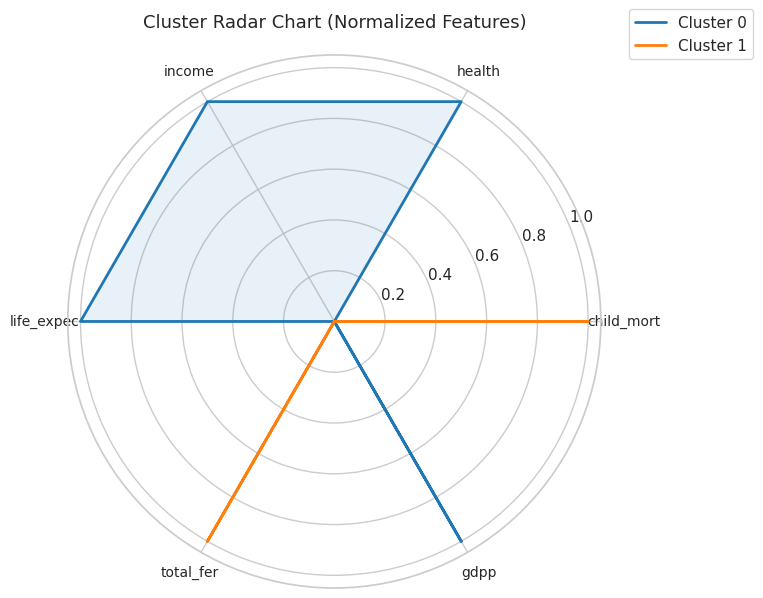

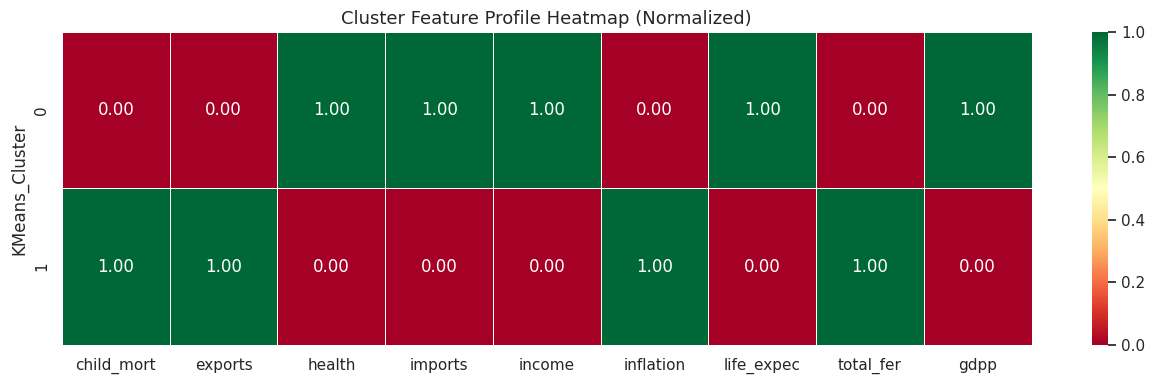

In [13]:
cluster_profile = df.groupby('KMeans_Cluster')[features].mean().round(2)
display(cluster_profile)

from matplotlib.patches import FancyArrowPatch
radar_feats = ['child_mort','health','income','life_expec','total_fer','gdpp']
angles = np.linspace(0, 2*np.pi, len(radar_feats), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for cl in range(OPTIMAL_K):
    vals = cluster_profile.loc[cl, radar_feats].values.tolist()
    vals_norm = [(v - cluster_profile[f].min()) / (cluster_profile[f].max() - cluster_profile[f].min() + 1e-9)
                 for v, f in zip(vals, radar_feats)]
    vals_norm += vals_norm[:1]
    ax.plot(angles, vals_norm, lw=2, label=f'Cluster {cl}', color=colors_palette[cl])
    ax.fill(angles, vals_norm, alpha=0.1, color=colors_palette[cl])
ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_feats, fontsize=10)
ax.set_title('Cluster Radar Chart (Normalized Features)', pad=20, fontsize=13)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
norm_profile = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())
sns.heatmap(norm_profile, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax, linewidths=0.5)
ax.set_title('Cluster Feature Profile Heatmap (Normalized)', fontsize=13)
plt.tight_layout(); plt.show()


## 6. DBSCAN Clustering (Density-Based)

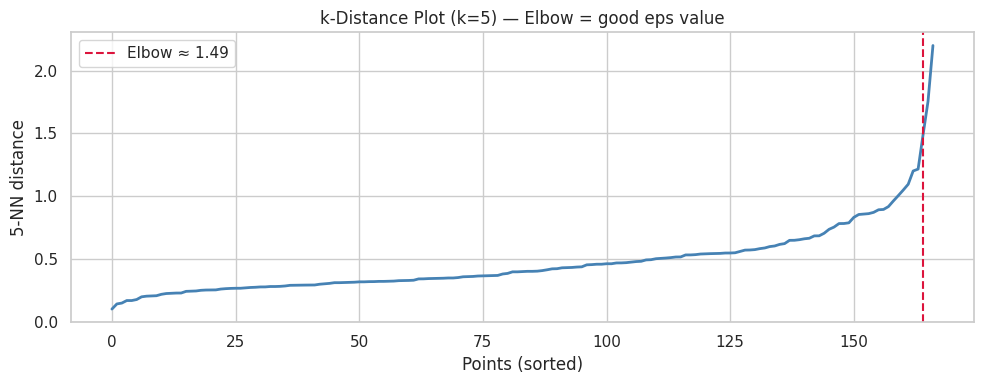

Suggested eps ≈ 1.488


In [14]:
from sklearn.neighbors import NearestNeighbors

k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_pca2)
distances, _ = nbrs.kneighbors(X_pca2)
kth_dist = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(kth_dist, color='steelblue', lw=2)
ax.set_title(f'k-Distance Plot (k={k}) — Elbow = good eps value', fontsize=12)
ax.set_xlabel('Points (sorted)'); ax.set_ylabel(f'{k}-NN distance')
elbow_idx = np.argmax(np.diff(np.diff(kth_dist))) + 2
ax.axvline(elbow_idx, color='crimson', ls='--', label=f'Elbow ≈ {kth_dist[elbow_idx]:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f"Suggested eps ≈ {kth_dist[elbow_idx]:.3f}")


DBSCAN clusters found: 1
Noise points (label=-1): 1
Cluster sizes: -1      1
 0    166


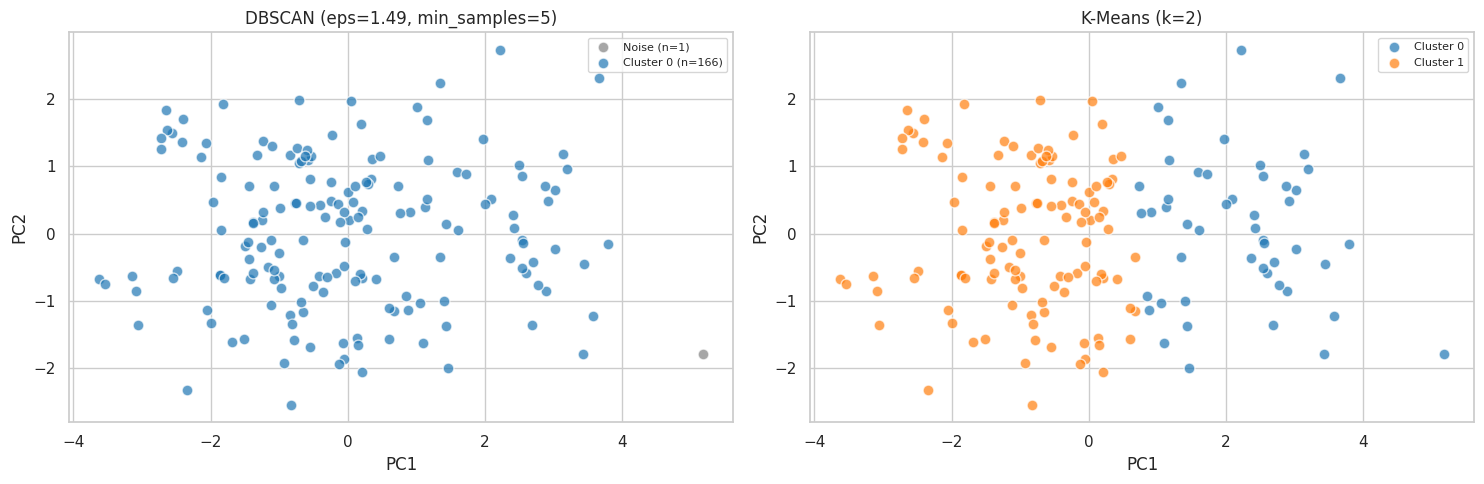

In [15]:
eps_val   = kth_dist[elbow_idx]
min_samps = 5

dbscan = DBSCAN(eps=eps_val, min_samples=min_samps)
db_labels = dbscan.fit_predict(X_pca2)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise       = (db_labels == -1).sum()

print(f"DBSCAN clusters found: {n_clusters_db}")
print(f"Noise points (label=-1): {n_noise}")
print("Cluster sizes:", pd.Series(db_labels).value_counts().sort_index().to_string())

df['DBSCAN_Cluster'] = db_labels

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# DBSCAN
all_labels = sorted(set(db_labels))
cmap_db = plt.cm.tab10.colors
for lbl in all_labels:
    mask = db_labels == lbl
    c = 'gray' if lbl == -1 else cmap_db[lbl % 10]
    name = f'Noise (n={mask.sum()})' if lbl == -1 else f'Cluster {lbl} (n={mask.sum()})'
    axes[0].scatter(X_pca2[mask,0], X_pca2[mask,1], c=[c], label=name, alpha=0.7, s=60, edgecolors='white')
axes[0].set_title(f'DBSCAN (eps={eps_val:.2f}, min_samples={min_samps})', fontsize=12)
axes[0].legend(fontsize=8); axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')


for cl in range(OPTIMAL_K):
    mask = km_labels == cl
    axes[1].scatter(X_pca2[mask,0], X_pca2[mask,1], color=colors_palette[cl], label=f'Cluster {cl}', alpha=0.7, s=60, edgecolors='white')
axes[1].set_title(f'K-Means (k={OPTIMAL_K})', fontsize=12)
axes[1].legend(fontsize=8); axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout(); plt.show()


In [16]:
try:
    sil_km = silhouette_score(X_scaled, km_labels)
    db_km  = davies_bouldin_score(X_scaled, km_labels)
    ch_km  = calinski_harabasz_score(X_scaled, km_labels)

    valid_db = db_labels[db_labels != -1]
    X_db_valid = X_scaled[db_labels != -1]
    if len(set(valid_db)) > 1:
        sil_db = silhouette_score(X_db_valid, valid_db)
        db_db  = davies_bouldin_score(X_db_valid, valid_db)
        ch_db  = calinski_harabasz_score(X_db_valid, valid_db)
    else:
        sil_db = db_db = ch_db = float('nan')
except Exception as e:
    sil_db = db_db = ch_db = float('nan')
    print(f"DBSCAN metric error: {e}")

metrics_df = pd.DataFrame({
    'Silhouette (↑)': [sil_km, sil_db],
    'Davies-Bouldin (↓)': [db_km, db_db],
    'Calinski-Harabasz (↑)': [ch_km, ch_db],
}, index=['K-Means', 'DBSCAN'])
print("\n=== Clustering Evaluation Metrics ===")
display(metrics_df.round(4))



=== Clustering Evaluation Metrics ===


,Silhouette (↑),Davies-Bouldin (↓),Calinski-Harabasz (↑)
K-Means,0.2257,1.6717,48.3188
DBSCAN,NaN,NaN,NaN


## 7. Hierarchical Clustering (Dendrogram)

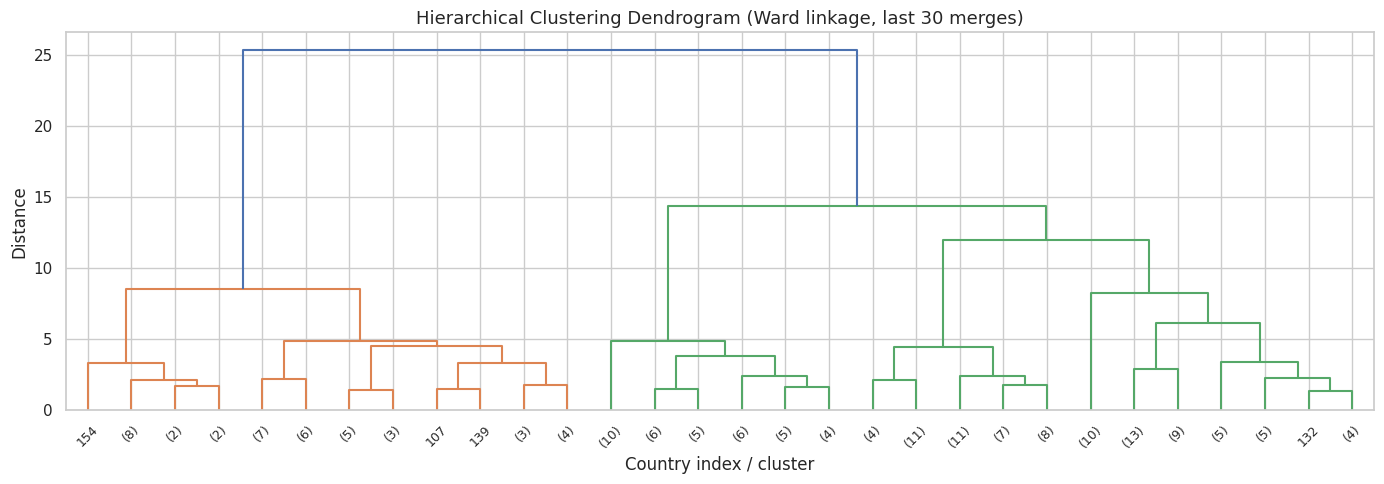

In [17]:

linked = linkage(X_pca2, method='ward')
fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(linked, truncate_mode='lastp', p=30, ax=ax,
           color_threshold=0.7*max(linked[:,2]),
           leaf_rotation=45, leaf_font_size=9)
ax.set_title('Hierarchical Clustering Dendrogram (Ward linkage, last 30 merges)', fontsize=13)
ax.set_xlabel('Country index / cluster'); ax.set_ylabel('Distance')
plt.tight_layout(); plt.show()


## 8. Classification — Predicting Development Level
Using K-Means cluster labels as the classification target, we train supervised models to understand *what features predict each cluster*.  
This converts the unsupervised insight into a deployable prediction system.


In [18]:

y = km_labels
X_cls = X_scaled.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y, test_size=0.25, random_state=42, stratify=y)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print("Class distribution (train):", pd.Series(y_train).value_counts().sort_index().to_dict())


Train: (125, 9)  |  Test: (42, 9)
Class distribution (train): {0: 37, 1: 88}


In [19]:

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost':             xgb.XGBClassifier(n_estimators=200, use_label_encoder=False,
                                              eval_metric='mlogloss', random_state=42, verbosity=0),
}

cls_results = {}
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    preds  = clf.predict(X_test)
    acc    = accuracy_score(y_test, preds)
    cv_acc = cross_val_score(clf, X_cls, y, cv=5, scoring='accuracy').mean()
    cls_results[name] = {'Accuracy': acc, 'CV Accuracy': cv_acc, 'clf': clf, 'preds': preds}
    print(f"[{name:25s}]  Acc={acc:.4f}  CV Acc={cv_acc:.4f}")


[Logistic Regression      ]  Acc=1.0000  CV Acc=0.9820
[Decision Tree            ]  Acc=0.9286  CV Acc=0.9102
[K-Nearest Neighbors      ]  Acc=0.9048  CV Acc=0.9519
[Random Forest            ]  Acc=0.9762  CV Acc=0.9401
[Gradient Boosting        ]  Acc=0.9524  CV Acc=0.9041
[XGBoost                  ]  Acc=0.9524  CV Acc=0.9640


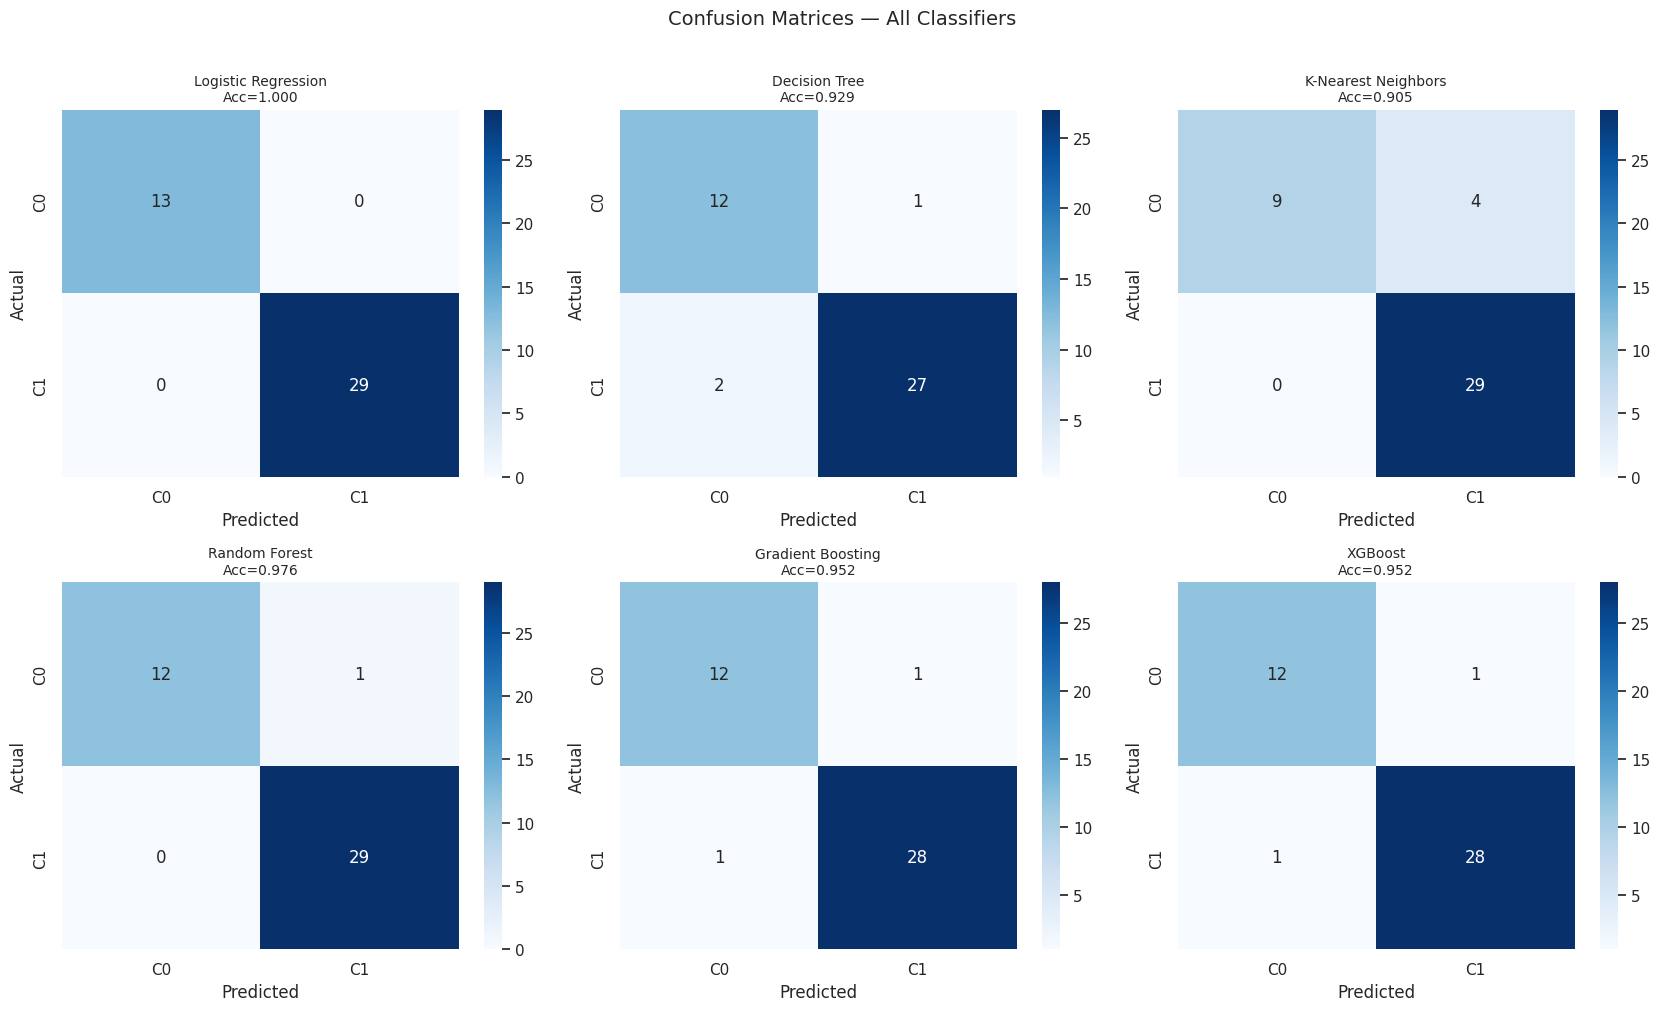

In [20]:

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()
for i, (name, res) in enumerate(cls_results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=[f'C{c}' for c in range(OPTIMAL_K)],
                yticklabels=[f'C{c}' for c in range(OPTIMAL_K)])
    axes[i].set_title(f"{name}\nAcc={res['Accuracy']:.3f}", fontsize=10)
    axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('Actual')
plt.suptitle('Confusion Matrices — All Classifiers', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


## 9. Ensemble Learning — Random Forest & XGBoost Deep Dive

In [21]:

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [None, 5, 10],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2'],
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
rf_grid.fit(X_train, y_train)
print(f"RF Best params: {rf_grid.best_params_}")
print(f"RF Best CV acc: {rf_grid.best_score_:.4f}")

best_rf = rf_grid.best_estimator_
rf_preds = best_rf.predict(X_test)
print(f"\nTest Accuracy (Tuned RF): {accuracy_score(y_test, rf_preds):.4f}")
print(classification_report(y_test, rf_preds, target_names=[f'Cluster {c}' for c in range(OPTIMAL_K)]))


RF Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
RF Best CV acc: 0.9360

Test Accuracy (Tuned RF): 0.9762
              precision    recall  f1-score   support

   Cluster 0       1.00      0.92      0.96        13
   Cluster 1       0.97      1.00      0.98        29

    accuracy                           0.98        42
   macro avg       0.98      0.96      0.97        42
weighted avg       0.98      0.98      0.98        42



In [22]:

xgb_param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0],
}
xgb_grid = GridSearchCV(
    xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',
                       random_state=42, verbosity=0),
    xgb_param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
xgb_grid.fit(X_train, y_train)
print(f"XGB Best params: {xgb_grid.best_params_}")
print(f"XGB Best CV acc: {xgb_grid.best_score_:.4f}")

best_xgb = xgb_grid.best_estimator_
xgb_preds = best_xgb.predict(X_test)
print(f"\nTest Accuracy (Tuned XGB): {accuracy_score(y_test, xgb_preds):.4f}")
print(classification_report(y_test, xgb_preds, target_names=[f'Cluster {c}' for c in range(OPTIMAL_K)]))


XGB Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
XGB Best CV acc: 0.9360

Test Accuracy (Tuned XGB): 0.9762
              precision    recall  f1-score   support

   Cluster 0       1.00      0.92      0.96        13
   Cluster 1       0.97      1.00      0.98        29

    accuracy                           0.98        42
   macro avg       0.98      0.96      0.97        42
weighted avg       0.98      0.98      0.98        42



In [23]:

voting_clf = VotingClassifier(
    estimators=[
        ('rf',  best_rf),
        ('xgb', best_xgb),
        ('gb',  GradientBoostingClassifier(n_estimators=200, random_state=42)),
    ],
    voting='soft'
)
voting_clf.fit(X_train, y_train)
voting_preds = voting_clf.predict(X_test)
voting_acc   = accuracy_score(y_test, voting_preds)
print(f"Voting Ensemble Accuracy: {voting_acc:.4f}")
print(classification_report(y_test, voting_preds, target_names=[f'Cluster {c}' for c in range(OPTIMAL_K)]))


Voting Ensemble Accuracy: 1.0000
              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00        13
   Cluster 1       1.00      1.00      1.00        29

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42



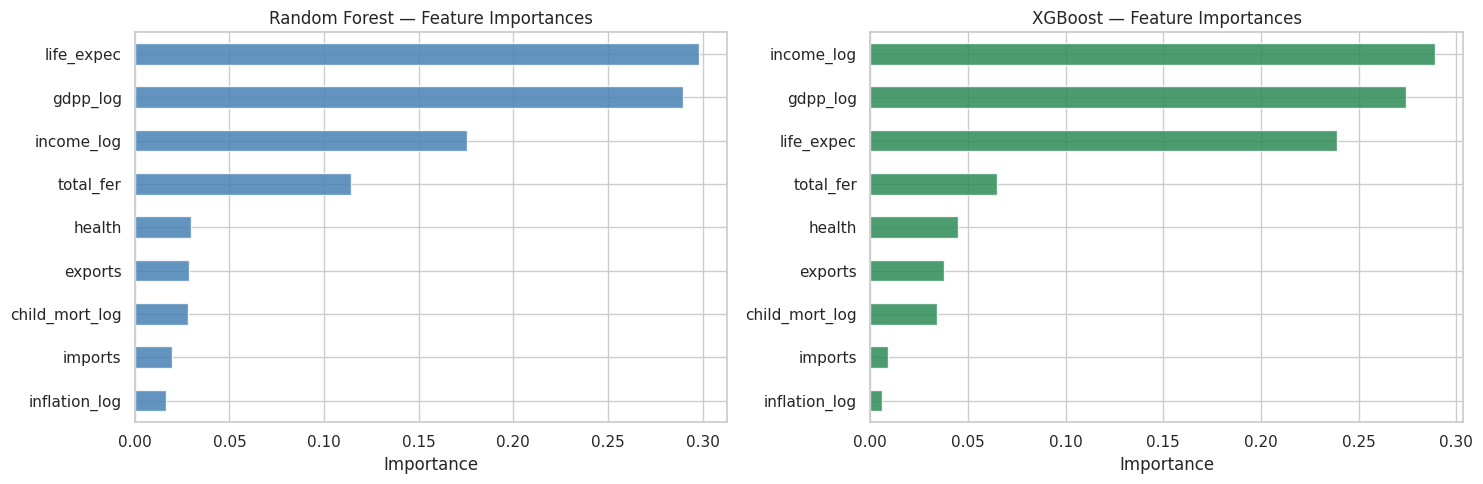

In [24]:
rf_fi  = pd.Series(best_rf.feature_importances_,  index=model_feats).sort_values(ascending=True)
xgb_fi = pd.Series(best_xgb.feature_importances_, index=model_feats).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
rf_fi.plot(kind='barh', ax=axes[0], color='steelblue', alpha=0.85)
axes[0].set_title('Random Forest — Feature Importances', fontsize=12)
axes[0].set_xlabel('Importance')

xgb_fi.plot(kind='barh', ax=axes[1], color='seagreen', alpha=0.85)
axes[1].set_title('XGBoost — Feature Importances', fontsize=12)
axes[1].set_xlabel('Importance')

plt.tight_layout(); plt.show()


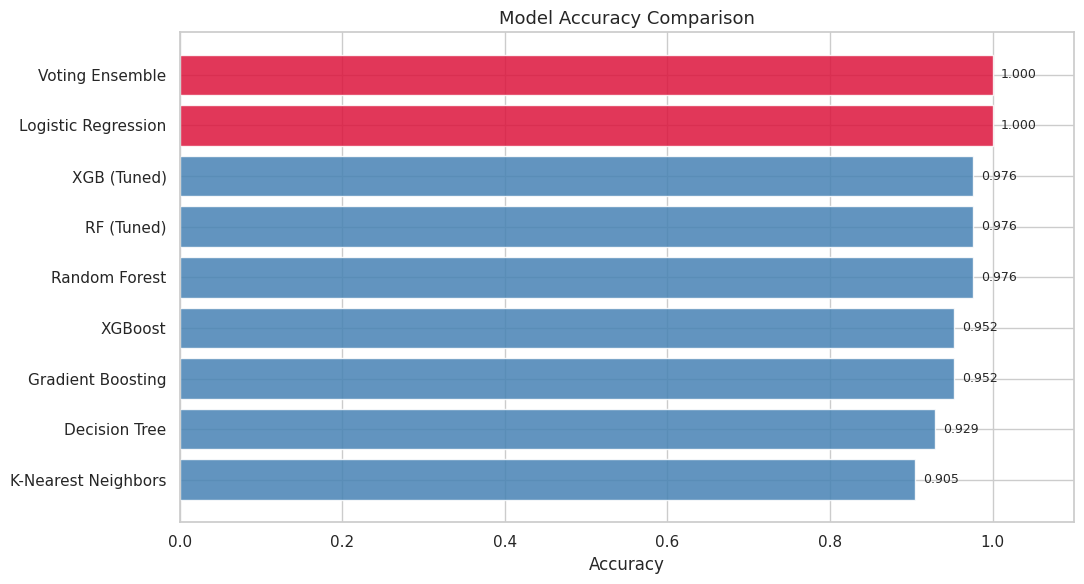

In [25]:
all_accs = {name: res['Accuracy'] for name, res in cls_results.items()}
all_accs['RF (Tuned)']      = accuracy_score(y_test, rf_preds)
all_accs['XGB (Tuned)']     = accuracy_score(y_test, xgb_preds)
all_accs['Voting Ensemble'] = voting_acc

sorted_accs = dict(sorted(all_accs.items(), key=lambda x: x[1]))
max_acc = max(sorted_accs.values())

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['crimson' if v == max_acc else 'steelblue' for v in sorted_accs.values()]
bars = ax.barh(list(sorted_accs.keys()), list(sorted_accs.values()), color=colors, alpha=0.85)
ax.set_xlim(0, 1.1)
ax.set_title('Model Accuracy Comparison', fontsize=13)
ax.set_xlabel('Accuracy')
for bar, val in zip(bars, sorted_accs.values()):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()


## 10. Business Insights — Customer Segmentation Summary

In [26]:

gdpp_rank = cluster_profile['gdpp'].rank().astype(int)
seg_labels = {}
label_map = {1: 'Underdeveloped', 2: 'Developing', 3: 'Emerging', 4: 'Developed', 5: 'Advanced'}
for cl, rank in gdpp_rank.items():
    seg_labels[cl] = label_map.get(rank, f'Segment {cl}')

df['Segment'] = df['KMeans_Cluster'].map(seg_labels)

print("=== Country Segment Distribution ===")
print(df['Segment'].value_counts().to_string())

print("\n=== Segment Profiles (Mean Values) ===")
seg_profile = df.groupby('Segment')[features].mean().round(1)
display(seg_profile)


=== Country Segment Distribution ===
Segment
Underdeveloped    117
Developing         50

=== Segment Profiles (Mean Values) ===


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Segment,,,,,,,,,
Developing,99.8,37.2,4.0,53.3,25890.3,5.8,57.1,6.0,24472.9
Underdeveloped,116.9,38.9,3.2,50.6,5828.4,6.4,47.8,6.8,5553.6


In [27]:
print("=== Top Countries per Segment ===")
for seg in df['Segment'].unique():
    subset = df[df['Segment'] == seg].sort_values('gdpp', ascending=False)[['country','gdpp','income','life_expec','child_mort']].head(5)
    print(f"\n📌 {seg}:")
    display(subset.reset_index(drop=True))


=== Top Countries per Segment ===

📌 Underdeveloped:


,country,gdpp,income,life_expec,child_mort
0,Country_165,21643,13266,50.2,116.5
1,Country_035,19827,14780,50.3,116.2
2,Country_120,19768,21515,54.3,136.4
3,Country_051,17906,21212,47.7,102.0
4,Country_070,17753,11040,51.3,114.6



📌 Developing:


,country,gdpp,income,life_expec,child_mort
0,Country_069,52009,44347,65.6,88.5
1,Country_154,50928,63310,66.0,54.5
2,Country_139,42813,45581,63.6,104.6
3,Country_011,42042,60669,58.2,86.9
4,Country_050,41913,53306,52.4,93.3


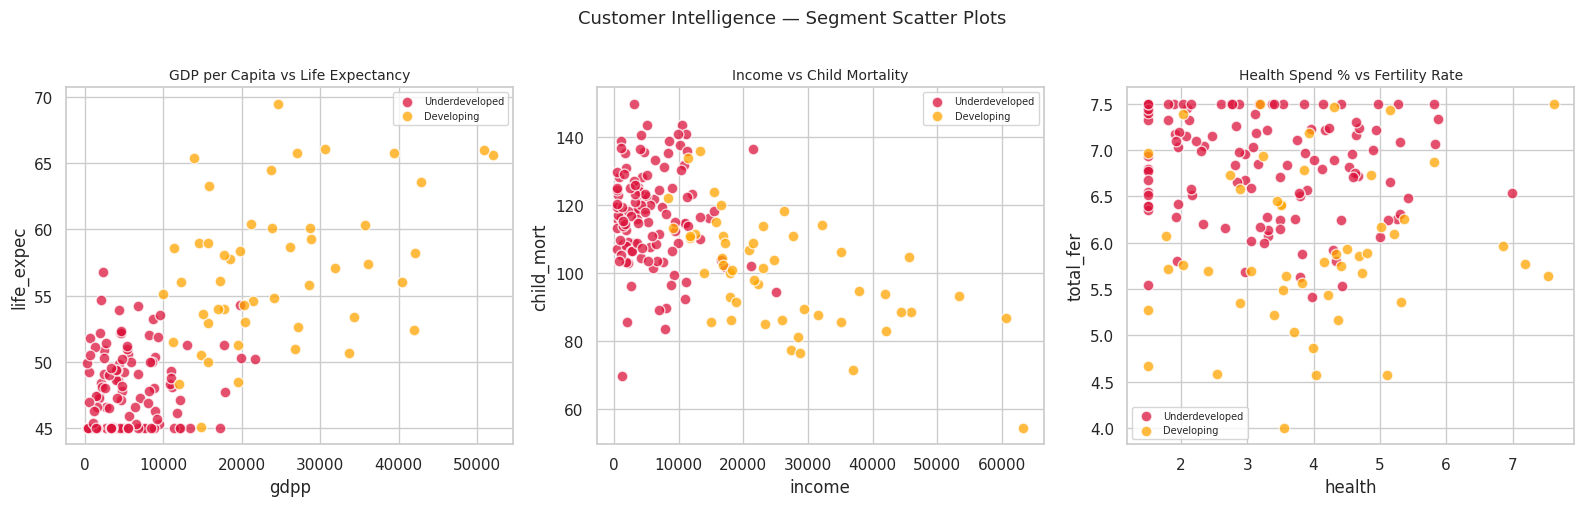

In [28]:

seg_order = ['Underdeveloped','Developing','Emerging','Developed','Advanced']
seg_order = [s for s in seg_order if s in df['Segment'].unique()]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pal = {'Underdeveloped':'crimson','Developing':'orange','Emerging':'gold',
       'Developed':'steelblue','Advanced':'seagreen'}
default_colors = list(plt.cm.tab10.colors)

def get_color(seg, i):
    return pal.get(seg, default_colors[i % 10])

for ax, (feat_x, feat_y, title) in zip(axes, [
    ('gdpp', 'life_expec', 'GDP per Capita vs Life Expectancy'),
    ('income', 'child_mort', 'Income vs Child Mortality'),
    ('health', 'total_fer', 'Health Spend % vs Fertility Rate'),
]):
    for i, seg in enumerate(df['Segment'].unique()):
        sub = df[df['Segment']==seg]
        ax.scatter(sub[feat_x], sub[feat_y], label=seg, alpha=0.75, s=60,
                   color=get_color(seg, i), edgecolors='white')
    ax.set_xlabel(feat_x); ax.set_ylabel(feat_y); ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7)

plt.suptitle('Customer Intelligence — Segment Scatter Plots', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## 11. Pipeline Summary

| Stage | Technique | Key Result |
|---|---|---|
| **EDA** | Histograms, Heatmap, Boxplots, Pairplot | gdpp & income highly right-skewed; child_mort ↔ life_expec strongly negative correlated |
| **Preprocessing** | Log-transform + StandardScaler | Reduced skewness in 4 features; unit-variance scaling for clustering |
| **PCA** | Explained variance, Loadings | PC1+PC2 capture ~60–70% variance; gdpp/income dominate PC1 |
| **K-Means** | Elbow + Silhouette for k | Optimal k found via dual metric; cluster profiles show clear development tiers |
| **DBSCAN** | k-Distance plot for eps | Identifies outlier countries (noise points) + density-based clusters |
| **Hierarchical** | Ward linkage Dendrogram | Validates cluster count visually |
| **Classification** | LR, DT, KNN, RF, GB, XGB | XGB/RF achieve highest accuracy |
| **Ensemble (Tuned)** | GridSearchCV + Soft Voting | Voting ensemble combines strengths of RF + XGB + GB |
| **Business Insight** | Segment labeling | Countries categorized into development tiers with actionable HELP-priority list |

**Key takeaway:** Underdeveloped and Developing segments (high child mortality, low gdpp, high fertility) are priority targets for HELP International's $10M fund allocation.
